# Step 1 : Finding the problem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
data = pd.read_csv('weight-height.csv')

In [3]:
data.shape

(10000, 3)

In [4]:
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  str    
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 234.5 KB


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.Weight.corr(data.Height)

np.float64(0.9247562987409146)

Text(0.5, 1.0, 'Height vs Weight')

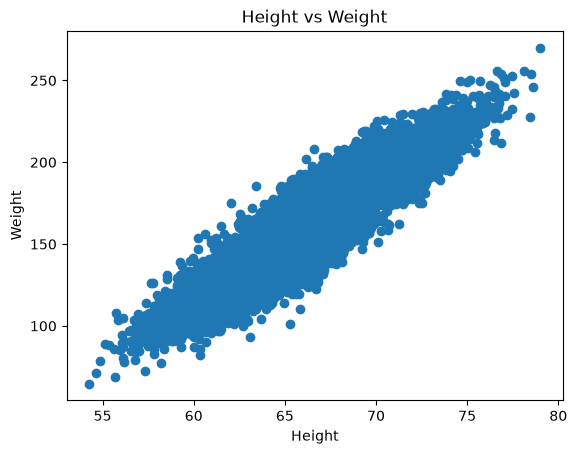

In [8]:
plt.scatter(x=data.Height,y=data.Weight)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')

# Step 2 : Separate input (predictor) and output (target) feature

In [9]:
X = data[['Height']]
y = data[['Weight']]

# Step 3 : Splitting the data into training and testing set

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

Text(0.5, 1.0, 'Height vs Weight')

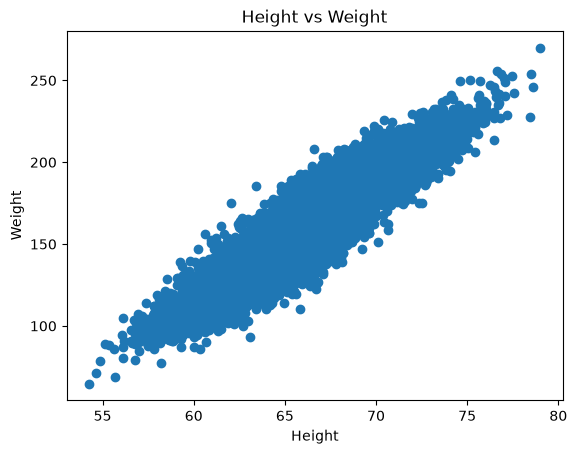

In [11]:
plt.scatter(X_train,y_train)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')

Text(0.5, 1.0, 'Height vs Weight')

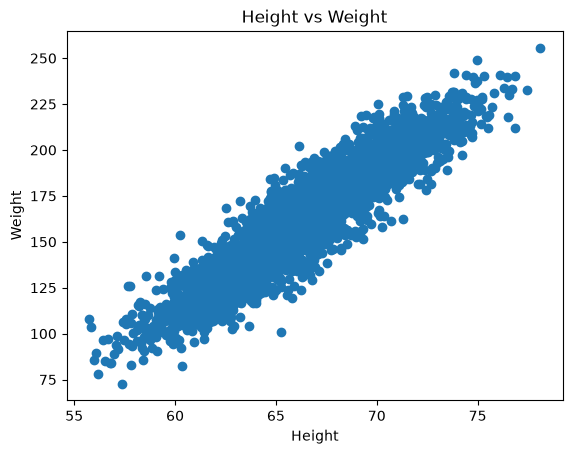

In [12]:
plt.scatter(X_test,y_test)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')

# Step 4 : Model selection

In [13]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# Step 5 : Fitting/Training the model
since we are doing supervised learning, we'll train the model by supplying data and labels (both x and y)

In [14]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[7.7]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Height']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-349.32]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [15]:
lr.coef_

array([[7.69542535]])

In [16]:
lr.intercept_

array([-349.32334861])

Weight = W (Height) + B

Weight = 7.7(Height) - 349.3

# Step 6 : Prediction on training data

In [17]:
y_pred_train = lr.predict(X_train)

# Step 7 : Model Performance Evaluation

In [18]:
from sklearn.metrics import r2_score , mean_squared_error

In [19]:
mean_squared_error(y_train,y_pred_train)

149.7046382455686

In [20]:
r2_score(y_train,y_pred_train)

0.8539725668285365

# Step 8 : Prediction on testing data

In [21]:
y_pred_test = lr.predict(X_test)

In [22]:
mean_squared_error(y_test,y_pred_test)

148.36229532793996

In [23]:
r2_score(y_test,y_pred_test)

0.8577298529881874

Text(0.5, 1.0, 'Height vs Weight')

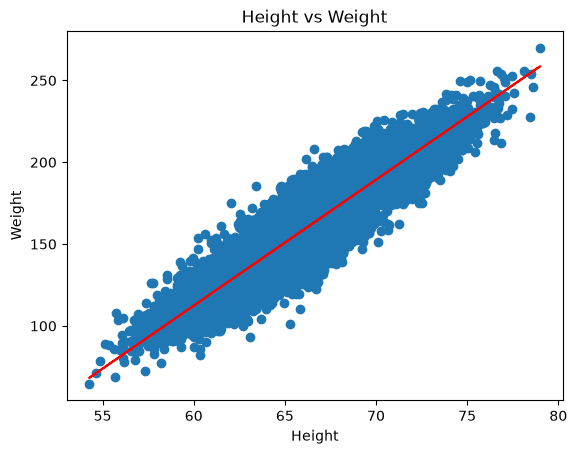

In [24]:
plt.scatter(x=data.Height,y=data.Weight)
plt.plot(X_train, y_pred_train, color='red')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')

In [25]:
def weight_prediction(height):
  weight = lr.predict([[height]])
  return weight

'''def weight_predictor(height):
  weight = lr.coef_ * height + lr.intercept_
  return weight'''

'def weight_predictor(height):\n  weight = lr.coef_ * height + lr.intercept_\n  return weight'

In [26]:
height_inch = float(input("Enter your height in ft"))*12
print(f"Your predicted weight is: {weight_prediction(height_inch)[0][0] * 0.453592}KG")

Your predicted weight is: 50.984726272800565KG


/var/data/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Multiple Linear Regression

In [27]:
data['Gender'] = data['Gender'].replace({'Male': 1, 'Female': 0})

In [28]:
data.head()

,Gender,Height,Weight
0,1,73.847017,241.893563
1,1,68.781904,162.310473
2,1,74.110105,212.740856
3,1,71.730978,220.042470
4,1,69.881796,206.349801


In [29]:
data.Height.corr(data.Weight)

np.float64(0.9247562987409146)

In [30]:
X = data[['Gender','Height']]
y = data[['Weight']]

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [32]:
mlr = LinearRegression()

In [33]:
mlr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 2)","[[19.4 , 5.96]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Gender','Height']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-243.95]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [34]:
mlr.coef_

array([[19.40445243,  5.96180802]])

In [35]:
mlr.intercept_

array([-243.94905106])

In [36]:
y_pred_train = mlr.predict(X_train)

In [37]:
r2_score(y_train,y_pred_train)

0.902443674513295

In [38]:
y_pred_test = mlr.predict(X_test)

In [39]:
r2_score(y_test,y_pred_test)

0.9033211309502138

In [40]:
def weight_prediction(gender, height):
    weight = mlr.predict(pd.DataFrame([[gender, height]], columns=['Gender','Height']))
    return weight

In [41]:
height_inch = float(input("Enter your height in ft: "))*12
Gender = int(input("Enter your gender (Male(1)/Female(0)): "))
print(f"Your predicted weight is: {weight_prediction(Gender,height_inch)[0][0] * 0.453592}KG")

Your predicted weight is: 51.6003673254298KG
